## Importing libraries and data

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape, test.shape)
print(train.head())

(7000, 6) (2000, 5)
   id  area     district  floor  distance_to_center  rent_price
0   0  84.2       suburb      4               11.59     2485.07
1   1  66.8       suburb      3                5.85     1383.59
2   2  61.1      central     11                1.43     2497.48
3   3  86.2  residential     14                5.64     2710.22
4   4  50.5      central      5                1.21     1494.48


## Analyzing the data

In [4]:
train.describe()

,id,area,floor,distance_to_center,rent_price
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,3499.500000,69.679229,9.356857,6.374836,3193.239619
std,2020.870275,29.730912,6.836826,3.931605,3080.368500
min,0.000000,18.000000,1.000000,0.200000,350.000000
25%,1749.750000,49.075000,4.000000,3.090000,1888.802500
50%,3499.500000,66.400000,8.000000,5.865000,2566.005000
75%,5249.250000,85.500000,12.000000,9.050000,3504.350000
max,6999.000000,260.000000,40.000000,21.510000,66216.610000


In [5]:
train.isna().sum()

id                    0
area                  0
district              0
floor                 0
distance_to_center    0
rent_price            0
dtype: int64

In [7]:
train['district'].value_counts()

district
residential     1241
suburb           993
university       821
business         768
central          690
industrial       595
riverside        583
old_town         528
green_zone       511
luxury_hills     270
Name: count, dtype: int64

In [12]:
train.groupby("district")['rent_price'].agg(["mean", "median", "std", "max"]).sort_values("mean", ascending=False)

,mean,median,std,max
district,,,,
luxury_hills,14992.374296,12951.070,7863.090070,66216.61
central,4195.589841,4078.900,1423.187453,11994.38
business,3711.798698,3547.925,1133.800101,9223.60
old_town,3084.287973,2931.000,1044.154423,9769.76
riverside,3001.599931,2869.950,1001.480360,7300.42
university,2659.085116,2553.450,933.835414,8833.77
green_zone,2591.760274,2481.140,907.661547,7999.79
residential,2166.909911,2095.130,808.221294,7431.90
suburb,2152.908530,2051.860,911.028121,6734.43


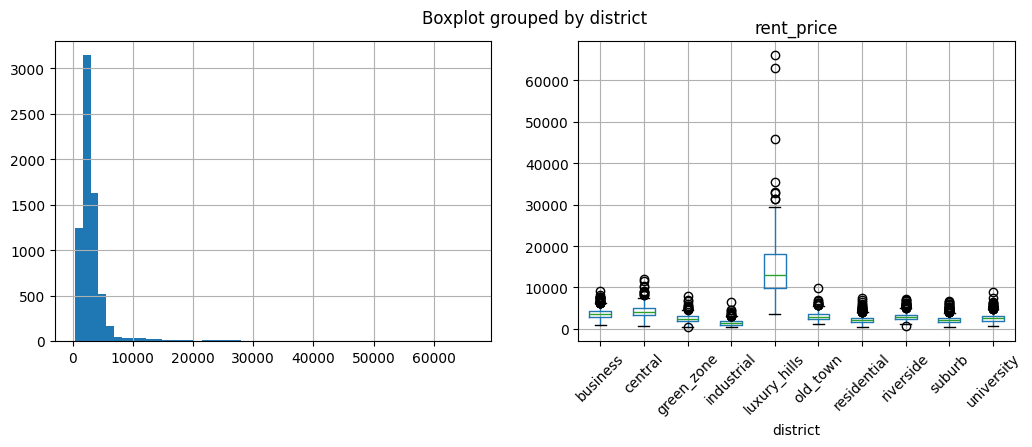

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['rent_price'].hist(ax=axes[0], bins=50)

train.boxplot(column="rent_price", by="district", rot=45, ax=axes[1])

plt.show()

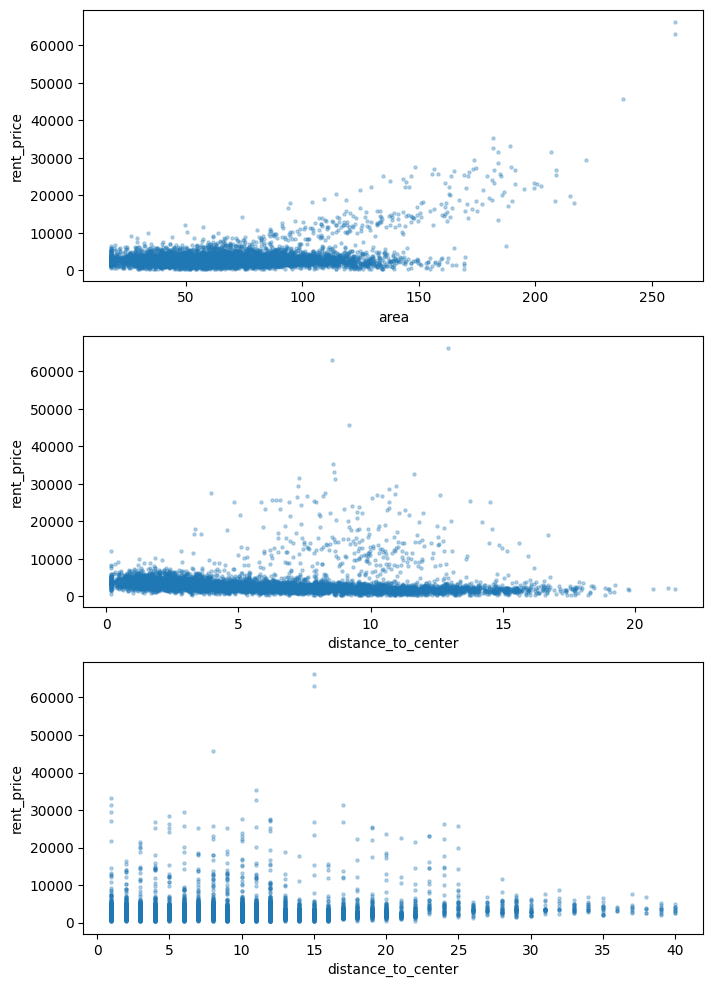

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))
axes[0].scatter(train['area'], train["rent_price"], s=5, alpha=0.3)
axes[0].set_xlabel("area")
axes[0].set_ylabel("rent_price")

axes[1].scatter(train["distance_to_center"], train["rent_price"], s=5, alpha=0.3)
axes[1].set_xlabel("distance_to_center")
axes[1].set_ylabel("rent_price")

axes[2].scatter(train["floor"], train["rent_price"], s=5, alpha=0.3)
axes[2].set_xlabel("distance_to_center")
axes[2].set_ylabel("rent_price")

plt.show()

In [19]:
features = ["area", "district", "floor", "distance_to_center"]
target = "rent_price"

X = train[features]
y = train[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## Only average result

In [21]:
district_avg = train.groupby("district")["rent_price"].mean()
average_only_pred = X_val['district'].map(district_avg)
print("Only average MAE:", mean_absolute_error(y_val, average_only_pred))

Only average MAE: 867.6796878727226


In [45]:
preprocess = ColumnTransformer(
    transformers=[("district_ohe", OneHotEncoder(handle_unknown="ignore"), ['district'])],
    remainder = "passthrough"
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ("gbr", GradientBoostingRegressor(
        loss = 'absolute_error',
        n_estimators = 500,
        max_depth = 4,
        learning_rate = 0.05,
        random_state = 42
    ))
])

model.fit(X_train, y_train)
val_pred = model.predict(X_val)

print("validation MAE:", mean_absolute_error(y_val, val_pred))

validation MAE: 779.8085317336491


In [46]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kf, scoring="neg_mean_absolute_error")
print("fold MAE", -scores)
print("mean MAE", -scores.mean())

fold MAE [779.80853173 801.39370258 752.24294856 741.63009459 835.53879526]
mean MAE 782.1228145455509


In [47]:
ohe = model.named_steps["preprocess"].named_transformers_["district_ohe"]
feat_names = list(ohe.get_feature_names_out(["district"])) + ["area", "floor", "distance_to_center"]
importances = model.named_steps['gbr'].feature_importances_

imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)
imp

distance_to_center       0.397926
district_luxury_hills    0.186692
area                     0.176910
district_industrial      0.073433
district_residential     0.043593
floor                    0.033625
district_business        0.023540
district_university      0.019185
district_suburb          0.015031
district_central         0.012846
district_riverside       0.011597
district_old_town        0.004585
district_green_zone      0.001038
dtype: float64

## Train the model

In [30]:
model.fit(X, y)

test_pred = model.predict(test[features])
test_pred = np.clip(test_pred, 0, None)

test_pred[:10]

array([2503.11446169, 3025.94746014, 3848.57393319, 1311.36651665,
       2487.44086997, 1828.93308343, 3259.87534777, 2226.84533935,
       2025.6262559 , 3124.86931499])

In [33]:
submission = pd.DataFrame({
    'id': test['id'],
    'rent_price': test_pred
})

submission.head()

,id,rent_price
0,7000,2503.114462
1,7001,3025.947460
2,7002,3848.573933
3,7003,1311.366517
4,7004,2487.440870


In [34]:
assert (submission['id'].values == pd.read_csv("sample_submission.csv")['id'].values).all()

submission.to_csv("submission.csv", index=False)
print("Saved")

Saved


In [50]:
print("The model using GradientBoostingRegressor:")
print("The validation MAE is 779.81")
print("AI Challenge score - 0.48")
print("AI Challenge High score - 0.55")
print("-"*50)

The model using GradientBoostingRegressor:
The validation MAE is 779.81
AI Challenge score - 0.48
AI Challenge High score - 0.55
--------------------------------------------------
